# **Comparación de Modelos Alternativos**

## **Introducción**

Luego de identificar que el modelo **XGBoost clásico** ofrecía el mejor rendimiento en el enfoque multiclase, el siguiente paso fue intentar **superarlo en desempeño predictivo (F1 macro)** o **mejorar su eficiencia computacional (CPU Time)**. Esta búsqueda derivó en un proceso experimental riguroso en el que se exploraron múltiples algoritmos de clasificación, distintas estrategias de balanceo de clases y técnicas de optimización hiperparamétrica.

Durante estas pruebas se aplicaron técnicas como **SMOTE, SMOTE-NC, ADASYN y SWIM** para mitigar el desbalance de clases. Además, se emplearon métodos avanzados de ajuste de hiperparámetros como **GridSearchCV, RandomizedSearchCV y Optuna**. Este proceso no solo confirmó la solidez del modelo XGBoost, sino que también permitió descubrir que una combinación **Stacking de XGBoost + LightGBM**, originalmente explorada como una alternativa más, ofrecía un balance notable entre desempeño y eficiencia.

A continuación, se presentan por separado los modelos evaluados en el enfoque binario (2 clases) y los aplicados a la clasificación multiclase (3 clases).

---

## **Modelos Evaluados – Clasificación Binaria (2 clases)**

| Modelo                                | F1 Macro | AUC    | CPU Time (s) |
|---------------------------------------|----------|--------|--------------|
| XGBoost (binario)                     | 0.6792   | 0.8143 | 46.63        |
| Stacking (XGBoost + LightGBM)         | 0.6659   | 0.7764 | 1.93         |
| Random Forest (binario)               | 0.6663   | 0.7872 | 193.99       |
| HistGradientBoosting (binario)        | 0.6647   | 0.8014 | 73.24        |
| XGBoost + ExtraTree                   | 0.6370   | 0.7419 | 2.22         |
| SMOTE + AdaBoost (RandomizedSearchCV) | 0.5858   | 0.6973 | 29.92        |
| Balanced Random Forest                | 0.5850   | 0.7515 | 45.16        |
| XGBoost (SWIM)                        | 0.6581   | 0.8277 | 40.80        |
| Extra Tree                            | 0.5810   | 0.6745 | 83.74        |
| Extreme Machine Learning + SMOTE      | 0.5749   | N/D    | 9.58         |







In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

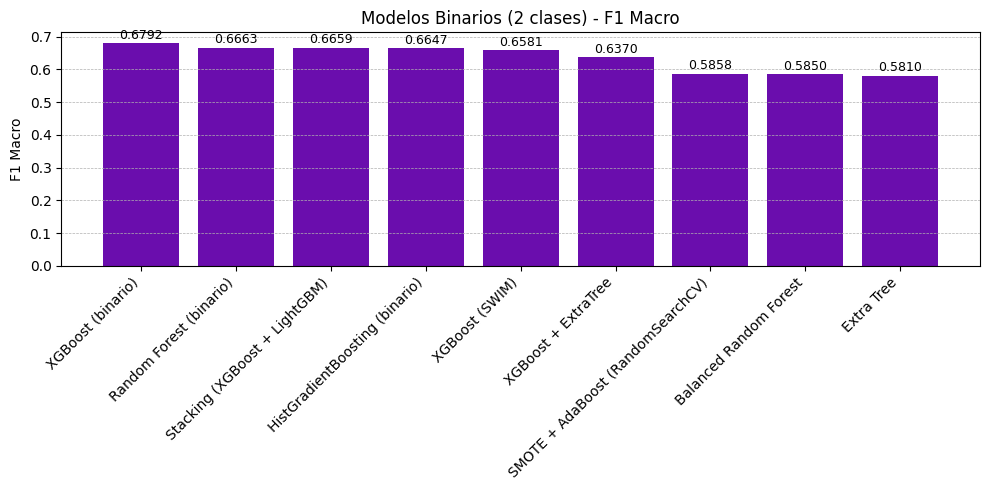

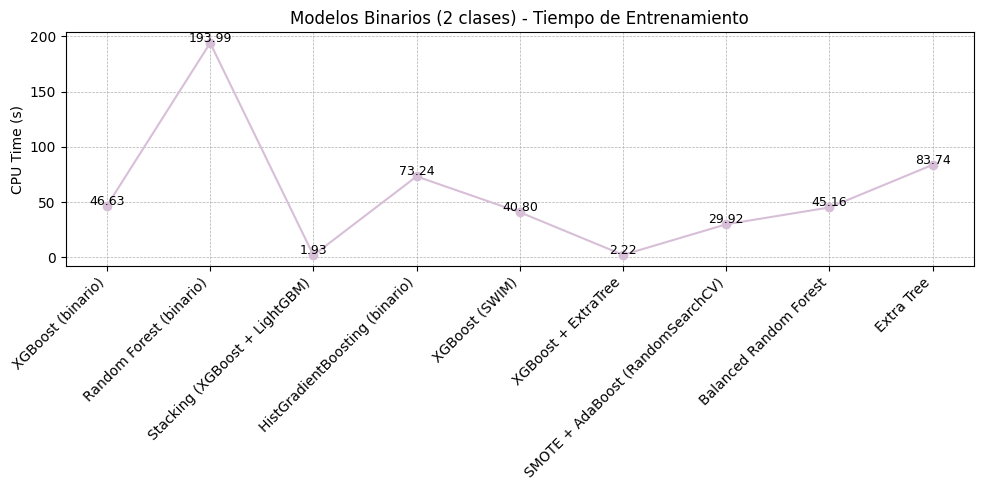

In [ ]:
# Modelos Binarios (2 clases)
data_binario = [
    {"Modelo": "XGBoost (binario)", "F1 Macro": 0.6792, "AUC": 0.8143, "CPU Time (s)": 46.63},
    {"Modelo": "Stacking (XGBoost + LightGBM)", "F1 Macro": 0.6659, "AUC": 0.7764, "CPU Time (s)": 1.93},
    {"Modelo": "Random Forest (binario)", "F1 Macro": 0.6663, "AUC": 0.7872, "CPU Time (s)": 193.99},
    {"Modelo": "HistGradientBoosting (binario)", "F1 Macro": 0.6647, "AUC": 0.8014, "CPU Time (s)": 73.24},
    {"Modelo": "XGBoost + ExtraTree", "F1 Macro": 0.6370, "AUC": 0.7419, "CPU Time (s)": 2.22},
    {"Modelo": "XGBoost (SWIM)", "F1 Macro": 0.6581, "AUC": 0.8277, "CPU Time (s)": 40.80},
    {"Modelo": "SMOTE + AdaBoost (RandomSearchCV)", "F1 Macro": 0.5858, "AUC": 0.6973, "CPU Time (s)": 29.92},
    {"Modelo": "Balanced Random Forest", "F1 Macro": 0.5850, "AUC": 0.7515, "CPU Time (s)": 45.16},
    {"Modelo": "Extra Tree", "F1 Macro": 0.5810, "AUC": 0.6745, "CPU Time (s)": 83.74},
    {"Modelo": "Extreme Machine Learning + SMOTE", "F1 Macro": 0.5749, "AUC": None, "CPU Time (s)": 9.58}
]

df_binario = pd.DataFrame(data_binario)

# F1 Macro (binario)
sorted_binario = df_binario.dropna().sort_values(by="F1 Macro", ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(sorted_binario['Modelo'], sorted_binario['F1 Macro'], color='#6A0DAD')
plt.ylabel("F1 Macro")
plt.title("Modelos Binarios (2 clases) - F1 Macro")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# CPU Time (binario)
plt.figure(figsize=(10, 5))
plt.plot(sorted_binario['Modelo'], sorted_binario['CPU Time (s)'], marker='o', linestyle='-', color='#D8BFD8')
plt.ylabel("CPU Time (s)")
plt.title("Modelos Binarios (2 clases) - Tiempo de Entrenamiento")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', linewidth=0.5)
for i, val in enumerate(sorted_binario['CPU Time (s)']):
    plt.text(i, val + 1, f"{val:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


## **Análisis de los Modelos Binarios**

- **XGBoost (binario):** Fue el punto de partida del enfoque binario. Obtuvo la **mejor F1 macro (0.6792)**, con un AUC alto (0.8143), pero su tiempo de entrenamiento fue considerable (46.63 s).

- **Stacking (XGBoost + LightGBM):** Descubierto durante la etapa experimental, este modelo alcanzó un F1 macro competitivo (0.6659) y un tiempo excepcionalmente bajo (1.93 s), convirtiéndose en la **solución más equilibrada entre rendimiento y eficiencia**.

- **Random Forest y HistGradientBoosting:** Ambos modelos se aproximaron a los resultados de XGBoost, con F1 macro por encima de 0.66, pero con tiempos de entrenamiento muy elevados, por lo que fueron descartados para uso práctico.

- **XGBoost + ExtraTree:** Esta combinación intentó complementar las capacidades del boosting con mayor diversidad. Ofreció un F1 macro de 0.6370 con buena eficiencia (2.22 s).

- **XGBoost con SWIM:** Utilizando una estrategia de balanceo novedosa, este modelo logró un AUC superior (0.8277), pero su F1 macro fue ligeramente inferior (0.6581) y el tiempo de ejecución, elevado.

- **Modelos con AdaBoost, Random Forest balanceado y Extreme Machine Learning:** Aunque ofrecieron tiempos moderados, sus F1 macro fueron considerablemente más bajos (rango: 0.5749–0.5858), y por tanto fueron descartados.


## **Modelos Evaluados – Clasificación Multiclase (3 clases)**

| Modelo                     | F1 Macro | AUC    | CPU Time (s) |
|----------------------------|----------|--------|--------------|
| XGBoost clásico            | 0.6700   | 0.7100 | 58.40        |
| HistGradientBoosting       | 0.4474   | 0.7505 | 296.07       |
| EasyEnsembleClassifier     | 0.3688   | 0.6849 | 597.09       |
| BalancedBaggingClassifier  | 0.3679   | 0.4753 | 0.36         |
| ImAdaBoost                 | 0.5372   | N/D    | N/D          |

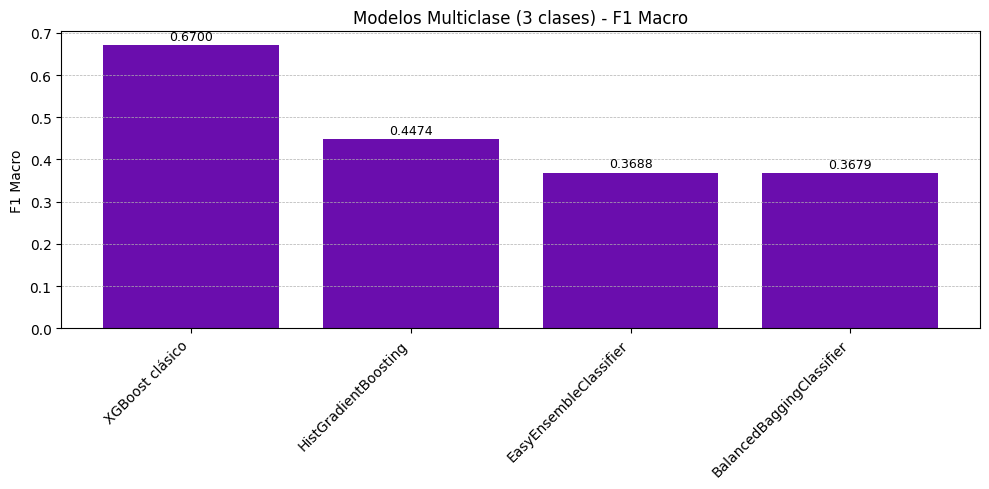

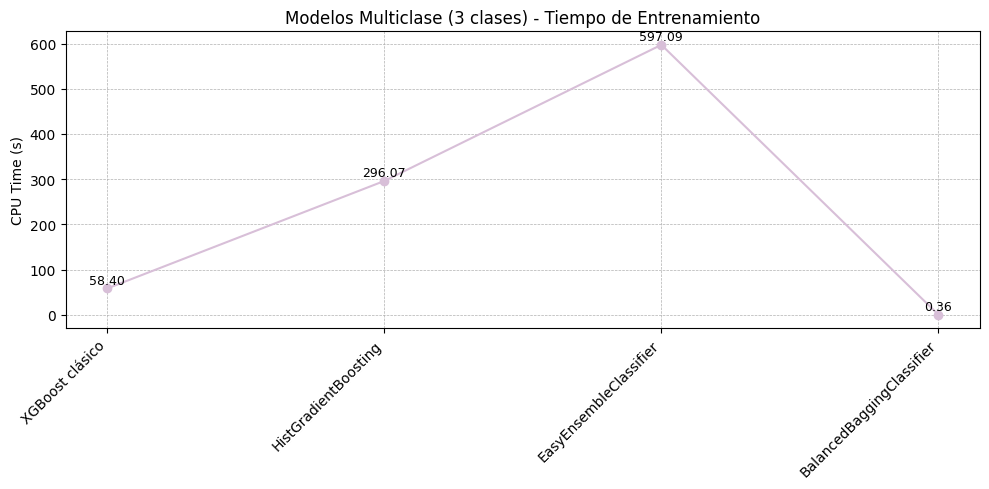

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Modelos Multiclase (3 clases)
data_multiclase = [
    {"Modelo": "XGBoost clásico", "F1 Macro": 0.6700, "AUC": 0.7100, "CPU Time (s)": 58.40},
    {"Modelo": "HistGradientBoosting", "F1 Macro": 0.4474, "AUC": 0.7505, "CPU Time (s)": 296.07},
    {"Modelo": "EasyEnsembleClassifier", "F1 Macro": 0.3688, "AUC": 0.6849, "CPU Time (s)": 597.09},
    {"Modelo": "BalancedBaggingClassifier", "F1 Macro": 0.3679, "AUC": 0.4753, "CPU Time (s)": 0.36},
    {"Modelo": "ImAdaBoost", "F1 Macro": 0.5372, "AUC": None, "CPU Time (s)": None}
]

df_multiclase = pd.DataFrame(data_multiclase)

# F1 Macro (multiclase)
sorted_multi_f1 = df_multiclase.dropna().sort_values(by="F1 Macro", ascending=False)
plt.figure(figsize=(10, 5))
bars = plt.bar(sorted_multi_f1['Modelo'], sorted_multi_f1['F1 Macro'], color='#6A0DAD')
plt.ylabel("F1 Macro")
plt.title("Modelos Multiclase (3 clases) - F1 Macro")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', linewidth=0.5)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.005, f"{height:.4f}", ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

# CPU Time (multiclase)
sorted_multi_time = df_multiclase.dropna().sort_values(by="F1 Macro", ascending=False)
plt.figure(figsize=(10, 5))
plt.plot(sorted_multi_time['Modelo'], sorted_multi_time['CPU Time (s)'], marker='o', linestyle='-', color='#D8BFD8')
plt.ylabel("CPU Time (s)")
plt.title("Modelos Multiclase (3 clases) - Tiempo de Entrenamiento")
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', linewidth=0.5)
for i, val in enumerate(sorted_multi_time['CPU Time (s)']):
    plt.text(i, val + 10, f"{val:.2f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()



## **Análisis de los Modelos Multiclase**

- **XGBoost clásico:** Se posicionó como el mejor modelo en el enfoque multiclase, con un F1 macro de 0.67 y AUC de 0.71. Fue el punto de comparación para todo el proyecto.

- **HistGradientBoosting:** A pesar de tener un AUC alto (0.7505), su F1 macro fue bajo (0.4474) y su tiempo de entrenamiento excesivo.

- **EasyEnsemble y BalancedBaggingClassifier:** Mostraron bajo desempeño en F1 macro, especialmente BalancedBagging, que además tuvo un AUC muy bajo. Fueron descartados para este problema.

- **ImAdaBoost:** A pesar de su enfoque adaptativo, su F1 macro (0.5372) y ausencia de métricas complementarias lo dejan por debajo de XGBoost.


## **Conclusión**

El proceso comparativo permitió confirmar que, aunque el modelo **XGBoost clásico binario** es fuerte en precisión, su costo computacional lo hace menos práctico. El modelo **Stacking (XGBoost + LightGBM)** emerge como la **mejor opción global**, con una F1 macro cercana al máximo alcanzado y un tiempo de entrenamiento extremadamente bajo.

Los modelos multiclase, en cambio, mostraron **rendimientos generales inferiores**, reforzando la decisión de reformular el problema como binario. Modelos como EasyEnsemble y BalancedBagging mostraron escaso valor agregado para este tipo de datos.

En conjunto, esta etapa permitió validar rigurosamente las decisiones de modelado y dejó establecida una solución sólida y reproducible para la predicción de desenlaces graves en víctimas de violencia basada en género.


## **Códigos Modelos Alternativos**

A continuación, se presenta el código y los resultados obtenidos de los modelos anteriormente mencionados.

### **Modelo XGBoost con Optuna**

[I 2025-06-02 17:36:28,236] A new study created in memory with name: no-name-efca5665-7f65-40cd-bf1c-3fae26655cd1


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-02 17:37:08,921] Trial 0 finished with value: 0.8008987779335577 and parameters: {'n_estimators': 63, 'max_depth': 7, 'learning_rate': 0.060605207181367554, 'min_child_weight': 8, 'subsample': 0.718568405957286, 'colsample_bytree': 0.8054205682764464, 'scale_pos_weight': 2.0739841043513976}. Best is trial 0 with value: 0.8008987779335577.
[I 2025-06-02 17:37:35,321] Trial 1 finished with value: 0.7602001982050025 and parameters: {'n_estimators': 35, 'max_depth': 6, 'learning_rate': 0.15008900519013105, 'min_child_weight': 6, 'subsample': 0.881170991257944, 'colsample_bytree': 0.6556782174704697, 'scale_pos_weight': 2.750520838871173}. Best is trial 0 with value: 0.8008987779335577.


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2025-06-02 17:38:08,628] Trial 2 finished with value: 0.42630812726168177 and parameters: {'n_estimators': 52, 'max_depth': 6, 'learning_rate': 0.013120325902822775, 'min_child_weight': 6, 'subsample': 0.7820224737342514, 'colsample_bytree': 0.9128566562150446, 'scale_pos_weight': 2.9932331766735105}. Best is trial 0 with value: 0.8008987779335577.
[I 2025-06-02 17:38:31,409] Trial 3 finished with value: 0.7175962863155426 and parameters: {'n_estimators': 31, 'max_depth': 6, 'learning_rate': 0.08494887393825414, 'min_child_weight': 9, 'subsample': 0.9701082153588578, 'colsample_bytree': 0.7987598929821217, 'scale_pos_weight': 2.621819657161812}. Best is trial 0 with value: 0.8008987779335577.
[I 2025-06-02 17:39:00,466] Trial 4 finished with value: 0.5695922996319996 and parameters: {'n_estimators': 37, 'max_depth': 7, 'learning_rate': 0.03434585064069051, 'min_child_weight': 3, 'subsample': 0.9870033703152019, 'colsample_bytree': 0.9996856480384029, 'scale_pos_weight': 3.7796351031

...

[I 2025-06-02 17:45:33,114] Trial 15 finished with value: 0.6629790002124076 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.18670294509522548, 'min_child_weight': 3, 'subsample': 0.7522800990514917, 'colsample_bytree': 0.7760075802765011, 'scale_pos_weight': 5.841601447998848}. Best is trial 13 with value: 0.8475661513216096.
[I 2025-06-02 17:46:10,176] Trial 16 finished with value: 0.7493269132304708 and parameters: {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.20441860679171084, 'min_child_weight': 2, 'subsample': 0.6635121500193634, 'colsample_bytree': 0.6855890487158632, 'scale_pos_weight': 3.6818001007470125}. Best is trial 13 with value: 0.8475661513216096.


/usr/local/lib/python3.11/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[I 2025-06-02 17:46:40,516] Trial 17 finished with value: 0.7721259626432359 and parameters: {'n_estimators': 83, 'max_depth': 3, 'learning_rate': 0.12100301197602858, 'min_child_weight': 10, 'subsample': 0.6059874259567156, 'colsample_bytree': 0.6085944725558463, 'scale_pos_weight': 1.8890986222576918}. Best is trial 13 with value: 0.8475661513216096.
📌 Mejores hiperparámetros encontrados: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.2878247674940245, 'min_child_weight': 1, 'subsample': 0.6649766285166165, 'colsample_bytree': 0.7380530756502361, 'scale_pos_weight': 1.0096331833183756}


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [17:46:42] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC ROC,CPU Time (s)
0,0.6565,0.6276,0.6388,0.8142,0.7552,12.8684


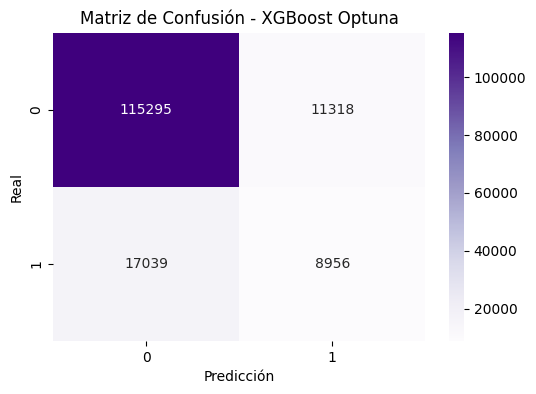

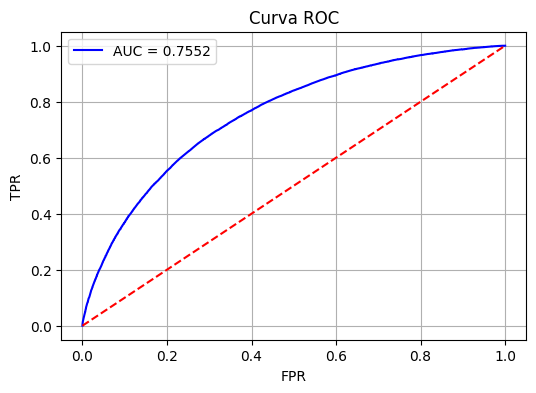

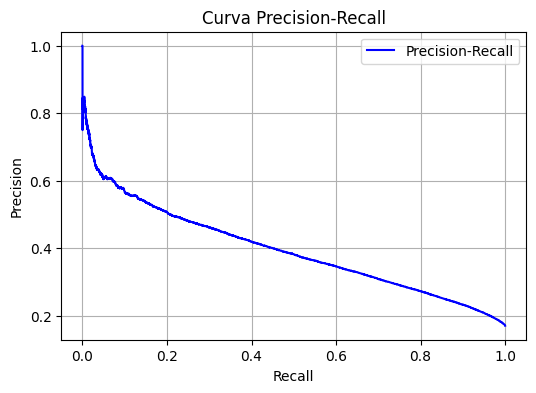

 Mejor umbral basado en F1: 0.36 (F1 = 0.4394)


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

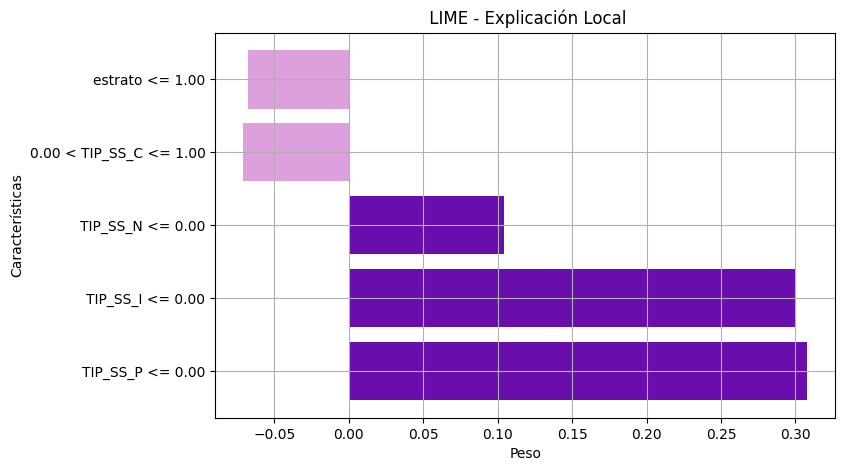

In [ ]:
#  Librerías necesarias
import pandas as pd
import numpy as np
import time
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score, make_scorer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

#  Cargar datos
Data = pd.read_csv("/content/drive/MyDrive/Entrega Final - Machine Learning PF/Data/DataFinal.csv")
X = Data.drop(columns=["Victima_Peligro", "Desenlace_Grave"])
y = Data["Victima_Peligro"]

#  División y balanceo con SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#  Función objetivo para Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 30, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 6.0),
        'use_label_encoder': False,
        'eval_metric': 'logloss',
        'n_jobs': -1,
        'random_state': 42
    }

    model = XGBClassifier(**params)

    # Cronómetro para limitar tiempo
    start_time = time.process_time()
    f1 = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        scoring=make_scorer(f1_score, average='macro'),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1
    ).mean()
    elapsed_time = time.process_time() - start_time

    # Penalizar si se excede el tiempo límite
    if elapsed_time > 2.0:
        return 0.0
    return f1

#  Optuna Study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, timeout=600, show_progress_bar=True)

#  Mejor modelo
best_params = study.best_trial.params
print("📌 Mejores hiperparámetros encontrados:", best_params)

#  Entrenar modelo final con mejores parámetros
final_model = XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss', n_jobs=-1, random_state=42)

start_cpu = time.process_time()
final_model.fit(X_train_smote, y_train_smote)
cpu_time = time.process_time() - start_cpu

#  Predicción
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

#  Métricas
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)
summary = pd.DataFrame({
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)": [report["macro avg"]["recall"]],
    "F1-score (Macro)": [report["macro avg"]["f1-score"]],
    "Accuracy": [report["accuracy"]],
    "AUC ROC": [roc_auc],
    "CPU Time (s)": [cpu_time]
})
display(HTML("<h3> Evaluación del Mejor Modelo XGBoost (Optuna)</h3>"))
display(summary.style.format("{:.4f}"))

#  Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - XGBoost Optuna")
plt.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

#  Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="blue", label="Precision-Recall")
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

print(f" Mejor umbral basado en F1: {best_threshold:.2f} (F1 = {best_f1:.4f})")

#  LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

exp = explainer.explain_instance(X_test.iloc[0], final_model.predict_proba, num_features=5)
lime_list = exp.as_list()
features, weights = zip(*lime_list)
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

plt.figure(figsize=(8, 5))
plt.barh(features, weights, color=colors)
plt.title(" LIME - Explicación Local")
plt.xlabel("Peso")
plt.ylabel("Características")
plt.grid(True)
plt.show()

### **LightGBM con Optuna**

[I 2025-06-02 18:03:01,275] A new study created in memory with name: no-name-9dff940a-c069-4a98-91f5-781e13335ea2


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-06-02 18:05:37,422] Trial 0 finished with value: 0.0 and parameters: {'n_estimators': 126, 'learning_rate': 0.059227153186474334, 'max_depth': 10, 'num_leaves': 45, 'min_child_samples': 90, 'subsample': 0.788285106963922, 'colsample_bytree': 0.718754390356257, 'scale_pos_weight': 1.5015881736179995}. Best is trial 0 with value: 0.0.
[I 2025-06-02 18:06:21,383] Trial 1 finished with value: 0.3830371387250954 and parameters: {'n_estimators': 68, 'learning_rate': 0.011833867297359205, 'max_depth': 3, 'num_leaves': 26, 'min_child_samples': 71, 'subsample': 0.7298505082355619, 'colsample_bytree': 0.995690104937921, 'scale_pos_weight': 5.276622252661054}. Best is trial 1 with value: 0.3830371387250954.
[I 2025-06-02 18:08:57,808] Trial 2 finished with value: 0.0 and parameters: {'n_estimators': 147, 'learning_rate': 0.024488636892059306, 'max_depth': 6, 'num_leaves': 40, 'min_child_samples': 91, 'subsample': 0.6515963685281861, 'colsample_bytree': 0.7538481696948662, 'scale_pos_weigh

,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC ROC,CPU Time (s)
0,0.6022,0.6782,0.5269,0.5613,0.7703,13.2730


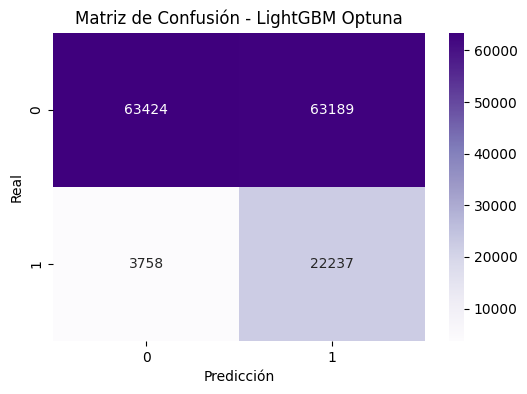

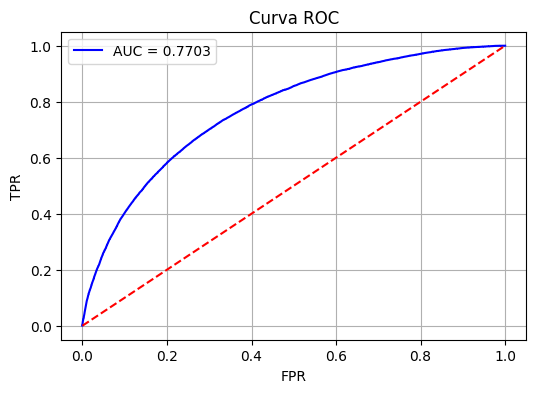

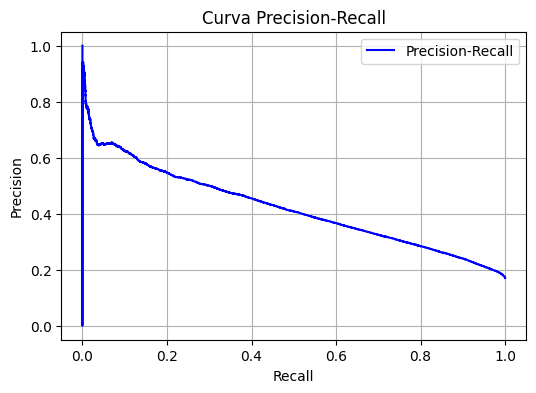

 Mejor umbral basado en F1: 0.71 (F1 = 0.4557)


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning: Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`
  ret[feature] = int(self.lambdas[feature](ret[feature]))
/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

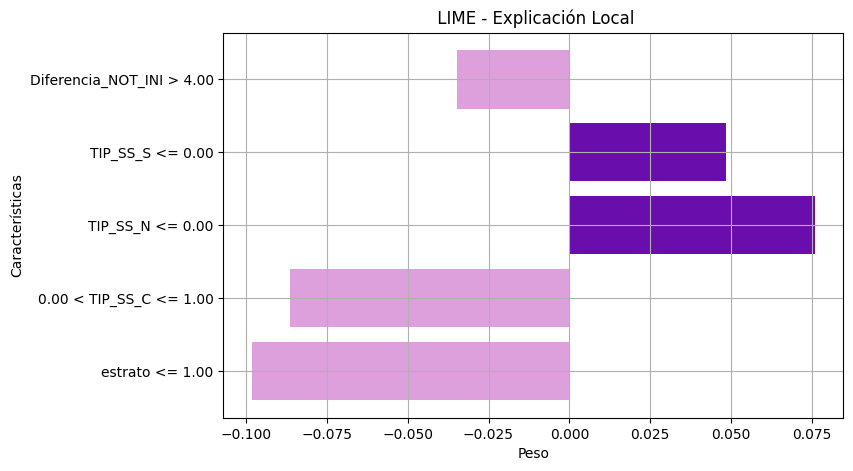

In [ ]:
#  Librerías necesarias
import pandas as pd
import numpy as np
import time
import optuna
import lightgbm as lgb
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score, make_scorer
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

# Cargar datos
Data = pd.read_csv("/content/drive/MyDrive/Entrega Final - Machine Learning PF/Data/DataFinal.csv")
X = Data.drop(columns=["Victima_Peligro", "Desenlace_Grave"])
y = Data["Victima_Peligro"]

#  División y balanceo con SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#  Función objetivo para Optuna
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 40, 150),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 60),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 6.0),
        'n_jobs': -1,
        'random_state': 42
    }

    model = lgb.LGBMClassifier(**params)
    start_time = time.process_time()
    f1 = cross_val_score(
        model,
        X_train_smote,
        y_train_smote,
        scoring=make_scorer(f1_score, average='macro'),
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        n_jobs=-1
    ).mean()
    elapsed = time.process_time() - start_time

    if elapsed > 2.0:
        return 0.0
    return f1

#  Optuna Study
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, timeout=600, show_progress_bar=True)

#  Mejores hiperparámetros
best_params = study.best_trial.params
print(" Mejores parámetros encontrados:", best_params)

#  Entrenar modelo final
final_model = lgb.LGBMClassifier(**best_params, n_jobs=-1, random_state=42)

start_cpu = time.process_time()
final_model.fit(X_train_smote, y_train_smote)
cpu_time = time.process_time() - start_cpu

#  Predicción
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]

#  Métricas
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)
summary = pd.DataFrame({
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)": [report["macro avg"]["recall"]],
    "F1-score (Macro)": [report["macro avg"]["f1-score"]],
    "Accuracy": [report["accuracy"]],
    "AUC ROC": [roc_auc],
    "CPU Time (s)": [cpu_time]
})
display(HTML("<h3> Evaluación del Modelo LightGBM (Optuna)</h3>"))
display(summary.style.format("{:.4f}"))

#  Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - LightGBM Optuna")
plt.show()

#  Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

#  Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="blue", label="Precision-Recall")
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

print(f" Mejor umbral basado en F1: {best_threshold:.2f} (F1 = {best_f1:.4f})")

#  LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

exp = explainer.explain_instance(X_test.iloc[0], final_model.predict_proba, num_features=5)
lime_list = exp.as_list()
features, weights = zip(*lime_list)
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

plt.figure(figsize=(8, 5))
plt.barh(features, weights, color=colors)
plt.title(" LIME - Explicación Local")
plt.xlabel("Peso")
plt.ylabel("Características")
plt.grid(True)
plt.show()

### **Extra Trees**

 CPU Time: 83.74 segundos

 Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.75      0.81     84409
           1       0.28      0.47      0.35     17330

    accuracy                           0.71    101739
   macro avg       0.58      0.61      0.58    101739
weighted avg       0.77      0.71      0.73    101739



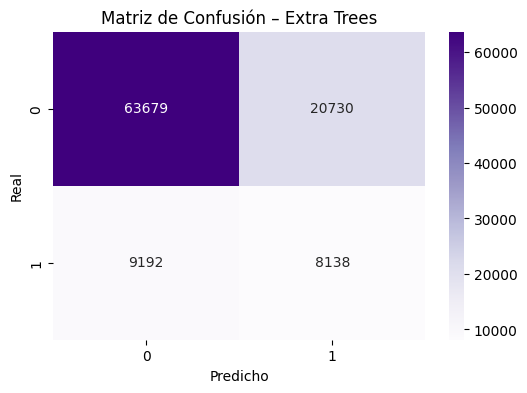

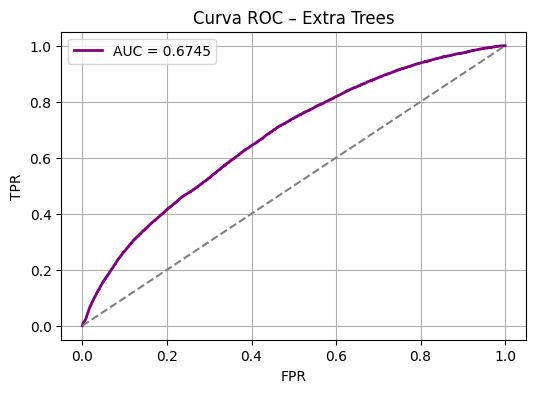

,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC,CPU Time (s)
0,0.5779,0.6120,0.5810,0.7059,0.6745,83.7393


In [ ]:
#  Librerías necesarias
import pandas as pd
import numpy as np
import time
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

#  Cargar los datos
Data = pd.read_csv("/content/drive/MyDrive/Entrega Final - Machine Learning PF/Data/DataFinal.csv")
X = Data.drop(columns=["Victima_Peligro", "Desenlace_Grave"])
y = Data["Victima_Peligro"]

#  Validación cruzada estratificada (1 fold usado para SMOTE + test)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_index, test_index in skf.split(X, y):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    break  # Solo el primer fold

#  Aplicar SMOTE una sola vez
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#  Modelo Extra Trees
et_model = ExtraTreesClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

#  Tiempo de CPU
cpu_start_et = time.process_time()
et_model.fit(X_train_smote, y_train_smote)
cpu_time_et = time.process_time() - cpu_start_et

# Predicción y Probabilidades
y_pred_et = et_model.predict(X_test)
y_proba_et = et_model.predict_proba(X_test)[:, 1]

#  Métricas
report_et = classification_report(y_test, y_pred_et, output_dict=True)
roc_auc_et = roc_auc_score(y_test, y_proba_et)
fpr, tpr, _ = roc_curve(y_test, y_proba_et)

#  Resultados
print(f" CPU Time: {cpu_time_et:.2f} segundos")
print("\n Classification Report:\n")
print(classification_report(y_test, y_pred_et))

#  Matriz de Confusión
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_et), annot=True, fmt='d',
            cmap='Purples', xticklabels=[0, 1], yticklabels=[0, 1])
plt.title("Matriz de Confusión – Extra Trees")
plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()

#  Curva ROC
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_et:.4f}", color="purple", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC – Extra Trees")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

#  Resumen en tabla
summary_et = pd.DataFrame({
    "Precision (Macro)": [report_et["macro avg"]["precision"]],
    "Recall (Macro)": [report_et["macro avg"]["recall"]],
    "F1-score (Macro)": [report_et["macro avg"]["f1-score"]],
    "Accuracy": [report_et["accuracy"]],
    "AUC": [roc_auc_et],
    "CPU Time (s)": [cpu_time_et]
})
display(HTML("<h3> Resumen de Métricas – Extra Trees</h3>"))
display(summary_et.style.format("{:.4f}"))


### **Stacking XGBoost y Extra Trees**

,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC ROC,CPU Time (s)
0,0.6297,0.6473,0.6370,0.7806,0.7419,2.2206


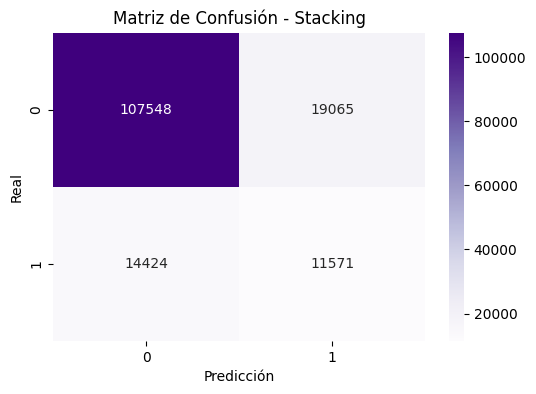

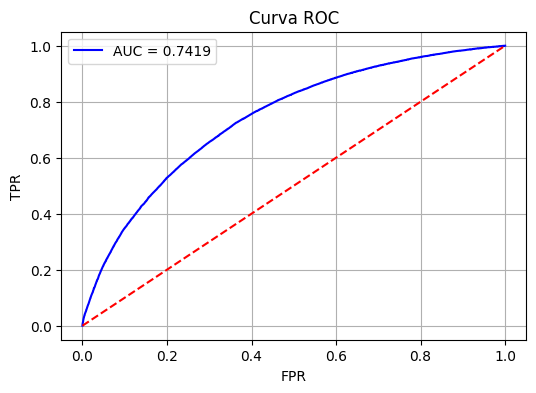

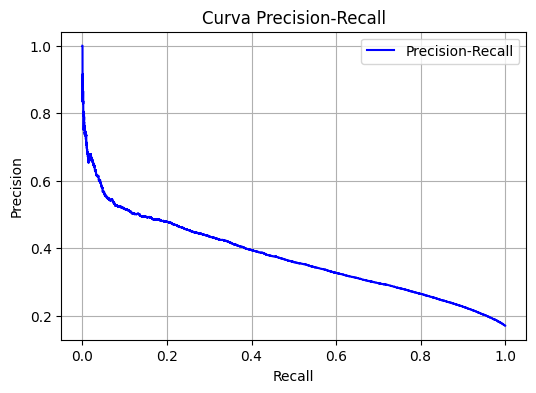

🔧 Mejor umbral basado en F1: 0.39 (F1 = 0.4245)


/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/python3.11/dist-packages/lime/discretize.py:110: FutureWarning:

Series.__setitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To set a value by position, use `ser.iloc[pos] = value`

/usr/local/lib/python3.11/dist-packages/lime/lime_tabular.py:544: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not 

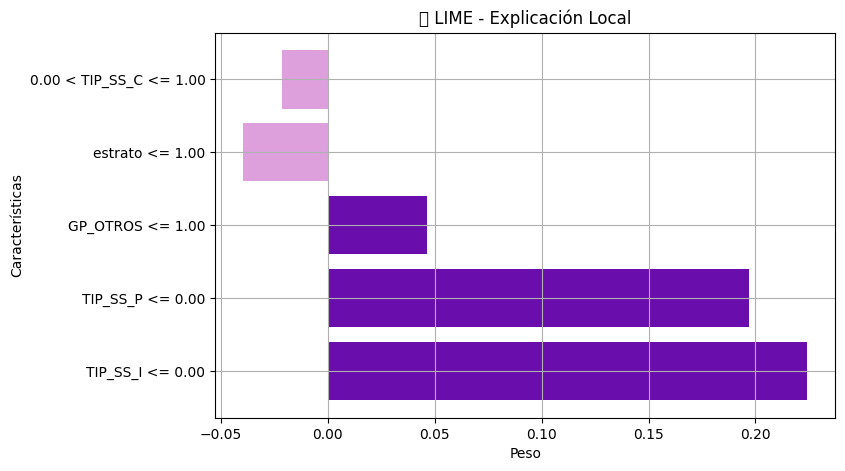

In [ ]:
# Librerías necesarias
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, f1_score
from sklearn.ensemble import StackingClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML

#  Cargar datos
Data = pd.read_csv("/content/drive/MyDrive/Entrega Final - Machine Learning PF/Data/DataFinal.csv")
X = Data.drop(columns=["Victima_Peligro", "Desenlace_Grave"])
y = Data["Victima_Peligro"]

#  División y balanceo con SMOTE
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=42)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

#  Modelos base
base_learners = [
    ('xgb', XGBClassifier(n_estimators=80, max_depth=4, learning_rate=0.1, n_jobs=-1, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1))
]

#  Meta-modelo
final_estimator = LogisticRegression(max_iter=200, solver='liblinear')

#  Stacking
stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=final_estimator,
    cv=3,
    n_jobs=-1,
    passthrough=False
)

#  CPU Time
start_cpu = time.process_time()
stack_model.fit(X_train_smote, y_train_smote)
cpu_time = time.process_time() - start_cpu

#  Predicciones
y_pred = stack_model.predict(X_test)
y_proba = stack_model.predict_proba(X_test)[:, 1]

#  Métricas
report = classification_report(y_test, y_pred, output_dict=True)
roc_auc = roc_auc_score(y_test, y_proba)
summary = pd.DataFrame({
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)": [report["macro avg"]["recall"]],
    "F1-score (Macro)": [report["macro avg"]["f1-score"]],
    "Accuracy": [report["accuracy"]],
    "AUC ROC": [roc_auc],
    "CPU Time (s)": [cpu_time]
})
display(HTML("<h3> Evaluación del Modelo Stacking</h3>"))
display(summary.style.format("{:.4f}"))

#  Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=[0, 1], yticklabels=[0, 1])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Stacking")
plt.show()

#  Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}", color="blue")
plt.plot([0, 1], [0, 1], linestyle="--", color="red")
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()

#  Curva Precision-Recall
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
best_thresh_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_thresh_idx]
best_f1 = f1_scores[best_thresh_idx]

plt.figure(figsize=(6, 4))
plt.plot(recall, precision, color="blue", label="Precision-Recall")
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.grid(True)
plt.legend()
plt.show()

print(f"🔧 Mejor umbral basado en F1: {best_threshold:.2f} (F1 = {best_f1:.4f})")

#  LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

exp = explainer.explain_instance(X_test.iloc[0], stack_model.predict_proba, num_features=5)
lime_list = exp.as_list()
features, weights = zip(*lime_list)
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

plt.figure(figsize=(8, 5))
plt.barh(features, weights, color=colors)
plt.title(" LIME - Explicación Local")
plt.xlabel("Peso")
plt.ylabel("Características")
plt.grid(True)
plt.show()


### **SMOTE + AdaBoost**


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import pandas as pd
import numpy as np
from joblib import Memory
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from imblearn.over_sampling import SMOTE
from lime.lime_tabular import LimeTabularExplainer
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.display import display, HTML

# 1) Pipeline SMOTE → Scaling → AdaBoost
memory = Memory("./cache_dir", verbose=0)
pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("ada", AdaBoostClassifier(random_state=42))
], memory=memory)

# 2) Distribución de parámetros
param_dist = {
    "ada__n_estimators":  [50, 100, 200],
    "ada__learning_rate": [0.5, 1.0]
}

# 3) RandomizedSearchCV para acelerar
rand_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=4,            # solo 4 combinaciones
    scoring="f1_macro",
    cv=3,                # 3 folds
    n_jobs=-1,
    verbose=2,
    random_state=42,
    error_score="raise"
)

# 4) Entrenamiento
start_time = time.process_time()
rand_search.fit(X_train_smote, y_train_smote)
training_time = time.process_time() - start_time

best_model = rand_search.best_estimator_
print("Mejores parámetros encontrados:", rand_search.best_params_)

# 5) Predicciones
y_pred      = best_model.predict(X_test)
y_proba_pos = best_model.predict_proba(X_test)[:, 1]

# 6) Reporte de clasificación
report = classification_report(y_test, y_pred, output_dict=True)

# 7) Métricas
accuracy_global = report["accuracy"]
roc_auc = roc_auc_score(y_test, y_proba_pos)

# 8) Matriz de Confusión
cm     = confusion_matrix(y_test, y_pred)
labels = sorted(np.unique(y_test))
z_text = [[str(v) for v in row] for row in cm]

fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labels],
    y=[f"True_{l}" for l in labels],
    annotation_text=z_text,
    colorscale="Purples"
)
fig_cm.update_layout(
    title_text="Matriz de Confusión – SMOTE + AdaBoost",
    xaxis=dict(title="Predicción"),
    yaxis=dict(title="Valor Real"),
    font=dict(family="Inter")
)
fig_cm.show()

# 9) Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_pos)
fig_roc = go.Figure([
    go.Scatter(
        x=fpr, y=tpr, mode="lines",
        name=f"AUC={roc_auc:.4f}", line=dict(color="darkmagenta", width=3)
    ),
    go.Scatter(
        x=[0,1], y=[0,1], mode="lines",
        name="Azar", line=dict(color="gray", dash="dash")
    )
])
fig_roc.update_layout(
    title="Curva ROC – SMOTE + AdaBoost",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter", size=13, color="black"),
    width=700, height=500
)
fig_roc.show()

# 10) Resumen de métricas
summary_data = {
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)"   : [report["macro avg"]["recall"]],
    "F1-score (Macro)" : [report["macro avg"]["f1-score"]],
    "Accuracy"         : [accuracy_global],
    "AUC"              : [roc_auc],
    "Training Time (s)": [training_time]
}
summary_df = pd.DataFrame(summary_data)
display(HTML("<h2>Resumen de Métricas – SMOTE + AdaBoost (RandomizedSearchCV)</h2>"))
display(summary_df.style.format("{:.4f}"))

# 11) LIME en tonos morados
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

idx = 0
exp = explainer.explain_instance(
    data_row=X_test.values[idx],
    predict_fn=best_model.predict_proba,
    num_features=5
)

features, weights = zip(*exp.as_list())
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

fig_lime = go.Figure(go.Bar(
    x=list(weights),
    y=list(features),
    orientation='h',
    marker=dict(color=colors)
))
fig_lime.update_layout(
    title_text="Explicación LIME – SMOTE + AdaBoost",
    xaxis_title="Peso de la característica",
    yaxis_title="Características",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter", color="black"),
    width=700, height=500
)
fig_lime.show()


Fitting 3 folds for each of 4 candidates, totalling 12 fits
Mejores parámetros encontrados: {'ada__n_estimators': 50, 'ada__learning_rate': 0.5}


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC,Training Time (s)
0,0.5867,0.6348,0.5858,0.6909,0.6973,29.9179


### **HistGradientBoosting (Binario)**

In [ ]:
# Pipeline con HistGB + early stopping
hgb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("hgb", HistGradientBoostingClassifier(
        class_weight="balanced",       # penaliza la clase mayoritaria
        learning_rate=0.1,
        max_iter=200,                  # número máximo de iteraciones
        early_stopping="auto",         # para cuando no mejore la loss
        validation_fraction=0.1,       # 10% del train como validación interna
        n_iter_no_change=10,           # 10 rondas sin mejora → stop
        random_state=42
    ))
])

# Entrenamiento
start = time.process_time()
hgb_pipeline.fit(X_train_smote, y_train_smote)
train_time = time.process_time() - start
print(f"✔️   Entrenado en {train_time:.2f}s")

# Predicción y métricas sobre X_test / y_test
y_pred     = hgb_pipeline.predict(X_test)
y_proba    = hgb_pipeline.predict_proba(X_test)[:,1]

# Classification report
rep = classification_report(y_test, y_pred, output_dict=True)
display(HTML("<h2>Classification Report – HistGB</h2>"))
display(pd.DataFrame(rep).transpose().style.format("{:.4f}"))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
labs = sorted(np.unique(y_test))
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labs],
    y=[f"True_{l}" for l in labs],
    annotation_text=[[str(v) for v in row] for row in cm],
    colorscale="Purples"
)
fig_cm.update_layout(
    title_text="Matriz de Confusión – HistGB",
    xaxis_title="Predicción", yaxis_title="Valor Real",
    font=dict(family="Inter")
)
fig_cm.show()

# Curva ROC
auc_ = roc_auc_score(y_test, y_proba)
fpr, tpr, _ = roc_curve(y_test, y_proba)
fig_roc = go.Figure([
    go.Scatter(x=fpr, y=tpr, mode="lines",
               name=f"AUC={auc_:.4f}", line=dict(color="darkmagenta", width=3)),
    go.Scatter(x=[0,1], y=[0,1], mode="lines",
               name="Azar", line=dict(color="gray", dash="dash"))
])
fig_roc.update_layout(
    title="Curva ROC – HistGB",
    xaxis_title="False Positive Rate", yaxis_title="True Positive Rate",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="Inter"), width=700, height=500
)
fig_roc.show()

# Resumen de métricas
summary = {
    "Precision (Macro)": [rep["macro avg"]["precision"]],
    "Recall (Macro)"   : [rep["macro avg"]["recall"]],
    "F1-score (Macro)" : [rep["macro avg"]["f1-score"]],
    "Accuracy"         : [rep["accuracy"]],
    "AUC"              : [auc_],
    "Train Time (s)"   : [train_time]
}
display(HTML("<h2>Resumen de Métricas – HistGradientBoosting</h2>"))
display(pd.DataFrame(summary).style.format("{:.4f}"))

# Explicación LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro","Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

exp = explainer.explain_instance(
    data_row=X_test.values[0],
    predict_fn=hgb_pipeline.predict_proba,
    num_features=5
)
feats, wts = zip(*exp.as_list())
cols = ['#6A0DAD' if w>0 else '#DDA0DD' for w in wts]

fig_lime = go.Figure(go.Bar(
    x=list(wts), y=list(feats),
    orientation='h',
    marker=dict(color=cols)
))
fig_lime.update_layout(
    title_text="Explicación LIME – HistGB",
    xaxis_title="Peso de la característica",
    yaxis_title="Características",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family="Inter"), width=700, height=500
)
fig_lime.show()


✔️   Entrenado en 73.24s


,precision,recall,f1-score,support
0,0.8748,0.9421,0.9072,84408.0000
1,0.5488,0.3430,0.4222,17330.0000
accuracy,0.8401,0.8401,0.8401,0.8401
macro avg,0.7118,0.6426,0.6647,101738.0000
weighted avg,0.8192,0.8401,0.8246,101738.0000


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC,Train Time (s)
0,0.7118,0.6426,0.6647,0.8401,0.8014,73.2393


### **Balanced Random Forest (BRF)**


In [ ]:
# --- Pipeline con Balanced Random Forest ---
memory = Memory("./cache_dir", verbose=0)

brf_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("brf", BalancedRandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
], memory=memory)

param_grid = {
    "brf__n_estimators": [100, 200],
    "brf__max_depth"  : [3, 6]
}

grid_search = GridSearchCV(
    estimator=brf_pipeline,
    param_grid=param_grid,
    scoring="f1_macro",
    cv=5,
    n_jobs=-1,
    error_score="raise"
)

start = time.process_time()
grid_search.fit(X_train, y_train)
train_time = time.process_time() - start

best_model = grid_search.best_estimator_
print("Mejores parámetros BRF:", grid_search.best_params_)

# Evaluación en X_test,y_test ---
y_pred      = best_model.predict(X_test)
y_proba_pos = best_model.predict_proba(X_test)[:,1]

report = classification_report(y_test, y_pred, output_dict=True)
acc    = report["accuracy"]
auc    = roc_auc_score(y_test, y_proba_pos)

# Matriz de confusión
cm     = confusion_matrix(y_test, y_pred)
labs   = sorted(np.unique(y_test))
z_txt  = [[str(v) for v in row] for row in cm]
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labs],
    y=[f"True_{l}" for l in labs],
    annotation_text=z_txt,
    colorscale="Purples"
)
fig_cm.update_layout(
    title_text="Matriz de Confusión – BRF",
    xaxis_title="Predicción",
    yaxis_title="Valor Real",
    font=dict(family="Inter")
)
fig_cm.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_pos)
fig_roc = go.Figure([
    go.Scatter(x=fpr, y=tpr, mode="lines",
               name=f"AUC={auc:.4f}", line=dict(color="darkmagenta", width=3)),
    go.Scatter(x=[0,1], y=[0,1], mode="lines",
               name="Azar", line=dict(color="gray", dash="dash"))
])
fig_roc.update_layout(
    title="Curva ROC – BRF",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="Inter"), width=700, height=500
)
fig_roc.show()

# Resumen de métricas
summary = {
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)"   : [report["macro avg"]["recall"]],
    "F1-score (Macro)" : [report["macro avg"]["f1-score"]],
    "Accuracy"         : [acc],
    "AUC"              : [auc],
    "Training Time (s)": [train_time]
}
df_sum = pd.DataFrame(summary)
display(HTML("<h2>Resumen de Métricas – BRF</h2>"))
display(df_sum.style.format("{:.4f}"))

# LIME
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=["No Peligro","Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

idx = 0
exp = explainer.explain_instance(
    data_row=X_test.values[idx],
    predict_fn=best_model.predict_proba,
    num_features=5
)

feat_wts = exp.as_list()
feats, wts  = zip(*feat_wts)
cols = ['#6A0DAD' if w>0 else '#DDA0DD' for w in wts]

fig_lime = go.Figure(go.Bar(
    x=list(wts), y=list(feats), orientation='h',
    marker=dict(color=cols)
))
fig_lime.update_layout(
    title_text="LIME – BRF",
    xaxis_title="Peso de la característica",
    yaxis_title="Características",
    plot_bgcolor="white", paper_bgcolor="white",
    font=dict(family="Inter"), width=700, height=500
)
fig_lime.show()


Mejores parámetros BRF: {'brf__max_depth': 6, 'brf__n_estimators': 200}


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC,Training Time (s)
0,0.6070,0.6854,0.5850,0.6516,0.7515,45.1627


### **Random Forest (binario)**


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import time
import pandas as pd
import numpy as np
from joblib import Memory
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
from sklearn.preprocessing import label_binarize
from lime.lime_tabular import LimeTabularExplainer
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.display import display, HTML

# 1) Definir caché y pipeline
memory = Memory("./cache_dir", verbose=0)
rf_pipeline = Pipeline([
    ("scaler", StandardScaler(copy=False)),
    ("rf", RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=100,
        max_depth=None,
        class_weight="balanced"
    ))
], memory=memory)

# Entrenamiento
start_time = time.process_time()
rf_pipeline.fit(X_train_smote, y_train_smote)
training_time = time.process_time() - start_time

# Predicciones y probabilidades de la clase positiva
y_pred     = rf_pipeline.predict(X_test)
y_proba_pos = rf_pipeline.predict_proba(X_test)[:, 1]

# Reporte de clasificación
report = classification_report(y_test, y_pred, output_dict=True)
accuracy_global = report["accuracy"]
display(HTML("<h2>Classification Report – Random Forest</h2>"))
display(pd.DataFrame(report).transpose().style.format("{:.4f}"))

# AUC binario
roc_auc = roc_auc_score(y_test, y_proba_pos)

# Matriz de confusión
cm     = confusion_matrix(y_test, y_pred)
labels = sorted(np.unique(y_test))
z_text = [[str(v) for v in row] for row in cm]
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labels],
    y=[f"True_{l}" for l in labels],
    annotation_text=z_text,
    colorscale="Purples"
)
fig_cm.update_layout(
    title_text="Matriz de Confusión – Random Forest",
    xaxis_title="Predicción",
    yaxis_title="Valor Real",
    font=dict(family="Inter")
)
fig_cm.show()

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba_pos)
fig_roc = go.Figure([
    go.Scatter(
        x=fpr, y=tpr, mode="lines",
        name=f"AUC={roc_auc:.4f}",
        line=dict(color="darkmagenta", width=3)
    ),
    go.Scatter(
        x=[0,1], y=[0,1], mode="lines",
        name="Azar", line=dict(color="gray", dash="dash")
    )
])
fig_roc.update_layout(
    title="Curva ROC – Random Forest",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter", size=13, color="black"),
    width=700, height=500
)
fig_roc.show()

# Resumen de métricas
summary_data = {
    "Precision (Macro)": [report["macro avg"]["precision"]],
    "Recall (Macro)"   : [report["macro avg"]["recall"]],
    "F1-score (Macro)" : [report["macro avg"]["f1-score"]],
    "Accuracy"         : [accuracy_global],
    "AUC"              : [roc_auc],
    "Training Time (s)": [training_time]
}
summary_df = pd.DataFrame(summary_data)
display(HTML("<h2>Resumen de Métricas – Random Forest</h2>"))
display(summary_df.style.format("{:.4f}"))

# Importancia de características
importances    = rf_pipeline.named_steps["rf"].feature_importances_
feature_names  = X_train_smote.columns
importance_df = pd.DataFrame({
    "Feature":    feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

fig_imp = go.Figure(go.Bar(
    x=importance_df["Feature"],
    y=importance_df["Importance"],
    marker_color="darkmagenta"
))
fig_imp.update_layout(
    title="Importancia de Características – Random Forest",
    xaxis_title="Características",
    yaxis_title="Importancia",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter", size=13, color="black")
)
fig_imp.show()

# LIME
explainer = LimeTabularExplainer(
    training_data=X_train_smote.values,
    feature_names=X_train_smote.columns.tolist(),
    class_names=["No Peligro", "Peligro"],
    mode="classification",
    discretize_continuous=True,
    random_state=42
)

idx = 0
exp = explainer.explain_instance(
    data_row=X_test.values[idx],
    predict_fn=rf_pipeline.predict_proba,
    num_features=5
)

features, weights = zip(*exp.as_list())
colors = ['#6A0DAD' if w > 0 else '#DDA0DD' for w in weights]

fig_lime = go.Figure(go.Bar(
    x=list(weights),
    y=list(features),
    orientation="h",
    marker=dict(color=colors)
))
fig_lime.update_layout(
    title_text="Explicación LIME – Random Forest",
    xaxis_title="Peso de la característica",
    yaxis_title="Características",
    plot_bgcolor="white",
    paper_bgcolor="white",
    font=dict(family="Inter", color="black"),
    width=700, height=500
)
fig_lime.show()


,precision,recall,f1-score,support
0,0.8777,0.9283,0.9023,84408.0000
1,0.5143,0.3699,0.4303,17330.0000
accuracy,0.8332,0.8332,0.8332,0.8332
macro avg,0.6960,0.6491,0.6663,101738.0000
weighted avg,0.8158,0.8332,0.8219,101738.0000


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC,Training Time (s)
0,0.6960,0.6491,0.6663,0.8332,0.7872,193.9913


### **BalancedBaggingClassifier**


In [ ]:
from joblib import Memory
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, f1_score, roc_auc_score
)
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.display import HTML

X_np = X.values if hasattr(X, "values") else X
y_np = y.values if hasattr(y, "values") else y

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.2, stratify=y_np, random_state=42
)

# Pipeline BalancedBaggingClassifier con muestreo automático
memory = Memory("./cache_dir", verbose=0)
pipe_bbc = Pipeline([
    ('scaler', StandardScaler(copy=False)),
    ('bbc', BalancedBaggingClassifier(
        estimator=DecisionTreeClassifier(max_depth=6),
        sampling_strategy='auto',
        n_estimators=50,
        n_jobs=-1,
        random_state=42
    ))
], memory=memory)

# Entrenamiento y CPU time
start_cpu = time.process_time()
pipe_bbc.fit(X_train, y_train)
cpu_time = time.process_time() - start_cpu
print(f"CPU Time: {cpu_time:.1f} s")

# Predicción y probabilidades
y_pred = pipe_bbc.predict(X_test)
y_proba = pipe_bbc.predict_proba(X_test)

# Métricas
report       = classification_report(y_test, y_pred, output_dict=True)
accuracy     = report['accuracy']
f1_macro     = report['macro avg']['f1-score']
y_test_bin   = label_binarize(y_test, classes=np.unique(y_test))
roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')

# Matriz de Confusión
cm     = confusion_matrix(y_test, y_pred)
labels = sorted(np.unique(y_test))
z_text = [[str(v) for v in row] for row in cm]
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labels],
    y=[f"True_{l}" for l in labels],
    annotation_text=z_text,
    colorscale='Purples'
)
fig_cm.update_layout(
    title_text="Matriz de Confusión - BalancedBaggingClassifier",
    xaxis=dict(title="Predicción"),
    yaxis=dict(title="Valor Real"),
    font=dict(family="Inter")
)
fig_cm.show()

# Curva ROC micro-average
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_micro = auc(fpr, tpr)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name=f"ROC micro-average (AUC={roc_micro:.4f})",
    line=dict(width=3)
))
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode='lines',
    name='Azar', line=dict(dash='dash')
))
fig_roc.update_layout(
    title="Curva ROC micro-average - BalancedBaggingClassifier",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family="Inter", size=13),
    width=700, height=500
)
fig_roc.show()

# Resumen de métricas
summary = {
    'Accuracy':         [accuracy],
    'F1-score (Macro)': [f1_macro],
    'AUC (Macro)':      [roc_auc_macro],
    'CPU Time (s)':     [cpu_time]
}
summary_df = pd.DataFrame(summary)
display(HTML("<h2>Resumen - BalancedBaggingClassifier</h2>"))
display(summary_df.style.format("{:.4f}"))


CPU Time: 0.4 s


,Accuracy,F1-score (Macro),AUC (Macro),CPU Time (s)
0,0.6039,0.3679,0.4753,0.3632


### **EasyEnsembleClassifier**

In [ ]:
from joblib import Memory
memory = Memory("./cache_dir", verbose=0)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.ensemble import EasyEnsembleClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
import time
import numpy as np
import pandas as pd
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.display import HTML

eec_pipeline = Pipeline([
    ('scaler', StandardScaler(copy=False)),
    ('eec', EasyEnsembleClassifier(random_state=42))
], memory=memory)

param_grid = {
    'eec__n_estimators': [10, 20]
}

grid_search = GridSearchCV(
    estimator=eec_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

start_time = time.process_time()
grid_search.fit(X_train_smote, y_train_smote)
training_time = time.process_time() - start_time

best_model = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Mejores parámetros encontrados:", best_params)

y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

report = classification_report(y_test, y_pred, output_dict=True)
accuracy_global = report["accuracy"]

unique_classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=unique_classes)
roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')

cm = confusion_matrix(y_test, y_pred)
labels = sorted(unique_classes)
z_text = [[str(val) for val in row] for row in cm]
fig_cm = ff.create_annotated_heatmap(
    z=cm,
    x=[f"Pred_{l}" for l in labels],
    y=[f"True_{l}" for l in labels],
    annotation_text=z_text,
    colorscale='Purples'
)
fig_cm.update_layout(
    title_text="Matriz de Confusión - EasyEnsemble",
    xaxis=dict(title="Predicción"),
    yaxis=dict(title="Valor Real"),
    font=dict(family="Inter")
)
fig_cm.show()

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_auc_micro = auc(fpr, tpr)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(
    x=fpr, y=tpr,
    mode='lines',
    name=f"ROC micro-average (AUC={roc_auc_micro:.4f})",
    line=dict(color='darkmagenta', width=3)
))
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1],
    mode='lines',
    name='Azar',
    line=dict(color='gray', dash='dash')
))
fig_roc.update_layout(
    title="Curva ROC micro-average - EasyEnsemble",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Inter", size=13, color="black"),
    width=700, height=500
)
fig_roc.show()

precision_macro = report['macro avg']['precision']
recall_macro = report['macro avg']['recall']
f1_macro = report['macro avg']['f1-score']

summary_data = {
    'Precision (Macro)': [precision_macro],
    'Recall (Macro)':    [recall_macro],
    'F1-score (Macro)':  [f1_macro],
    'Accuracy':          [accuracy_global],
    'AUC (Macro)':       [roc_auc_macro],
    'Training Time (s)': [training_time]
}
summary_df = pd.DataFrame(summary_data)
display(HTML("<h2>Resumen de Métricas - EasyEnsemble</h2>"))
display(summary_df.style.format("{:.4f}"))


Mejores parámetros encontrados: {'eec__n_estimators': 10}


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC (Macro),Training Time (s)
0,0.3857,0.5036,0.3688,0.6345,0.6849,597.0866


### **HistGradientBoostingClassifier (Multiclase)**


In [ ]:
import time
import numpy as np
import pandas as pd
from joblib import Memory
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, roc_auc_score
from imblearn.over_sampling import SMOTE
import plotly.figure_factory as ff
import plotly.graph_objects as go
from IPython.display import HTML

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# SMOTE solo sobre el train
sm = SMOTE(random_state=42)
X_train_smote, y_train_smote = sm.fit_resample(X_train, y_train)

memory = Memory("./cache_dir", verbose=0)

# Pipeline: scaler + HGB
hgb_pipeline = Pipeline([
    ('scaler', StandardScaler(copy=False)),
    ('hgb', HistGradientBoostingClassifier(
        early_stopping=True,
        class_weight='balanced'
    ))
], memory=memory)

# Grid de hiperparámetros
param_grid = {
    'hgb__max_iter': [100, 200],
    'hgb__max_leaf_nodes': [31, 63]
}

grid_search = GridSearchCV(
    estimator=hgb_pipeline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1,
    error_score='raise'
)

# Entrenamiento
start_cpu = time.process_time()
grid_search.fit(X_train_smote, y_train_smote)
cpu_elapsed = time.process_time() - start_cpu

best_model  = grid_search.best_estimator_
best_params = grid_search.best_params_
print("Mejores parámetros:", best_params)
print(f"CPU time (s): {cpu_elapsed:.2f}")

# Predicciones
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)

# Métricas y reportes
report = classification_report(y_test, y_pred, output_dict=True)
df_rep = pd.DataFrame(report).transpose()
f1_macro = report['macro avg']['f1-score']
accuracy = report['accuracy']

# AUC-macro multiclase
y_test_bin    = label_binarize(y_test, classes=np.unique(y))
roc_auc_macro = roc_auc_score(y_test_bin, y_proba, average='macro', multi_class='ovr')

# Matriz de confusión (Plotly)
cm = confusion_matrix(y_test, y_pred)
labels = sorted(np.unique(y_test))
z_text = [[str(val) for val in row] for row in cm]
fig_cm = ff.create_annotated_heatmap(
    z=cm, x=[f"Pred_{l}" for l in labels], y=[f"True_{l}" for l in labels],
    annotation_text=z_text, colorscale='Purples'
)
fig_cm.update_layout(
    title="Matriz de Confusión - HistGradientBoosting",
    xaxis=dict(title="Predicción"), yaxis=dict(title="Valor Real"),
    font=dict(family="Inter")
)
fig_cm.show()

# Curva ROC micro-average
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
roc_micro = auc(fpr, tpr)
fig_roc = go.Figure()
fig_roc.add_trace(go.Scatter(
    x=fpr, y=tpr, mode='lines',
    name=f"ROC micro-average (AUC={roc_micro:.4f})",
    line=dict(color='darkmagenta', width=3)
))
fig_roc.add_trace(go.Scatter(
    x=[0,1], y=[0,1], mode='lines',
    name='Azar', line=dict(color='gray', dash='dash')
))
fig_roc.update_layout(
    title="Curva ROC micro-average - HistGradientBoosting",
    xaxis_title="False Positive Rate", yaxis_title="True Positive Rate",
    plot_bgcolor='white', paper_bgcolor='white',
    font=dict(family="Inter", size=13, color="black"),
    width=700, height=500
)
fig_roc.show()

# Resumen
summary = {
    'Precision (Macro)': [report['macro avg']['precision']],
    'Recall (Macro)'   : [report['macro avg']['recall']],
    'F1-score (Macro)' : [f1_macro],
    'Accuracy'         : [accuracy],
    'AUC (Macro)'      : [roc_auc_macro],
    'CPU Time (s)'     : [cpu_elapsed]
}
summary_df = pd.DataFrame(summary)
display(HTML("<h2>Resumen de Métricas - HistGradientBoosting</h2>"))
display(summary_df.style.format("{:.4f}"))


Mejores parámetros: {'hgb__max_iter': 200, 'hgb__max_leaf_nodes': 63}
CPU time (s): 296.07


,Precision (Macro),Recall (Macro),F1-score (Macro),Accuracy,AUC (Macro),CPU Time (s)
0,0.4808,0.4316,0.4474,0.8425,0.7505,296.0658
